In [3]:
!pip install -U langchain-openrouter
!pip install langchain, langgraph, langchain_openai, langchain_core

ERROR: Invalid requirement: 'langchain,': Expected end or semicolon (after name and no valid version specifier)
    langchain,
             ^


In [4]:
import getpass
import os

if not os.getenv("OPENROUTER_API_KEY"):
    os.environ["OPENROUTER_API_KEY"] = '<openrouter-key>'

In [15]:
from langchain_openrouter import ChatOpenRouter

llm = ChatOpenRouter(
    # model="deepseek/deepseek-v4-flash",
    model="qwen/qwen3-next-80b-a3b-instruct",
    temperature=0,
    max_tokens=1024,
    max_retries=2,
    # other params...
)

In [16]:
llm.invoke('Hi, how are you doing and who created you?')

AIMessage(content="Hi there! 😊 I'm doing great—thanks for asking! I'm Qwen, a large-scale language model independently developed by the Tongyi Lab under Alibaba Group. My purpose is to assist you with answering questions, creating text, and providing information across a wide range of topics. Whether you need help with writing, learning, or just want to chat, I'm here for you! How can I assist you today? 🌟", additional_kwargs={}, response_metadata={'model_name': 'qwen/qwen3-next-80b-a3b-instruct-2509', 'id': 'gen-1780130139-oowRrRLRwnizbCtu4HtJ', 'created': 1780130139, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--019e7806-4c27-74e1-8344-5c7edabc7d16-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 90, 'total_tokens': 109, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 0}})

### Tool Calling

In [18]:
# Schema for structured output
from pydantic import BaseModel, Field


class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")

output


SearchQuery(search_query='relationship between calcium CT score and high cholesterol cardiovascular risk assessment', justification=None)

In [19]:

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")

# Get the tool call
msg.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': '10ce9ba987ae4a4f959bd73e5294da18',
  'type': 'tool_call'}]

## Prompt chaining

Prompt chaining is when each LLM call processes the output of the previous call. It’s often used for performing well-defined tasks that can be broken down into smaller, verifiable steps. Some examples include:
Translating documents into different languages
Verifying generated content for consistency
Prompt chaining


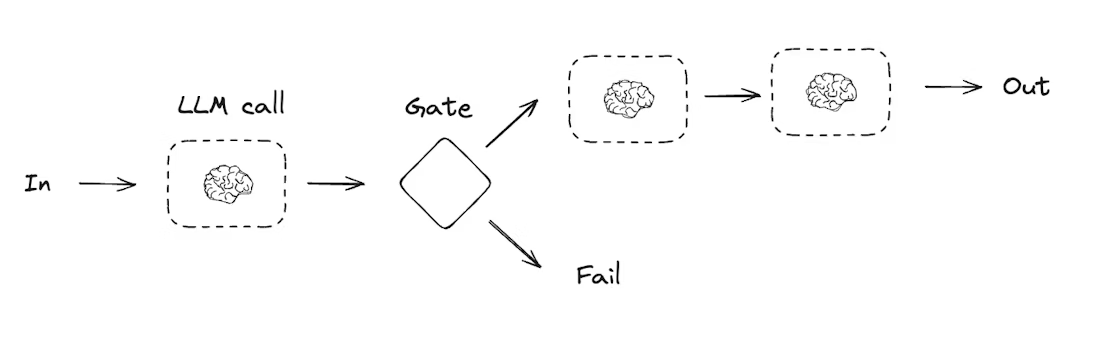

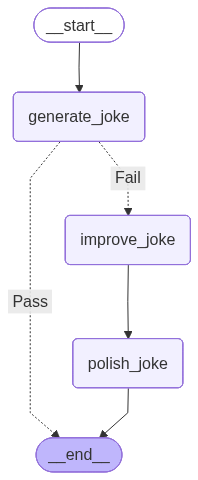

In [21]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))


In [25]:

# Invoke
state = chain.invoke({"topic": "Space"})
print(state)
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

{'topic': 'Space', 'joke': 'Why don’t astronauts ever throw parties in space?\n\nBecause there’s no *space* for dancing… and everyone’s just floating around like they’re at a bad wedding reception. 🚀💃'}
Initial joke:
Why don’t astronauts ever throw parties in space?

Because there’s no *space* for dancing… and everyone’s just floating around like they’re at a bad wedding reception. 🚀💃

--- --- ---

Final joke:
Why don’t astronauts ever throw parties in space?

Because there’s no *space* for dancing… and everyone’s just floating around like they’re at a bad wedding reception. 🚀💃


# Parallelization


Parallelization
With parallelization, LLMs work simultaneously on a task. This is either done by running multiple independent subtasks at the same time, or running the same task multiple times to check for different outputs. Parallelization is commonly used to:



*   Split up subtasks and run them in parallel, which increases speed
*   Run tasks multiple times to check for different outputs, which increases confidence


Some examples include:

*   Running one subtask that processes a document for keywords, and a second subtask to check for formatting errors
*   Running a task multiple times that scores a document for accuracy based on different criteria, like the number of citations, the number of sources used, and the quality of the sources

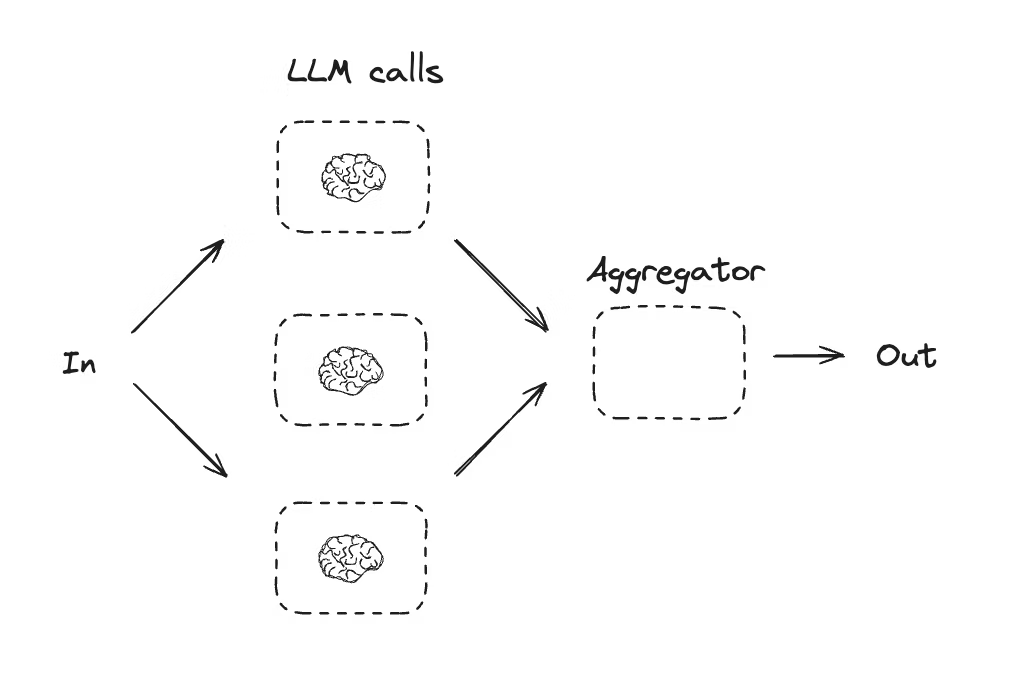

In [27]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}



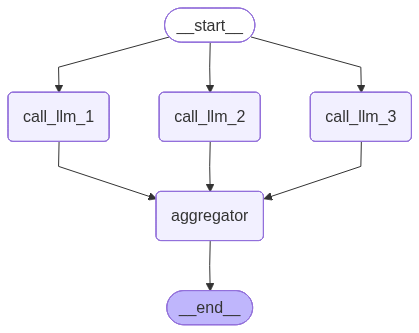

In [28]:

# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))


In [29]:

# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

Here's a story, joke, and poem about cats!

STORY:
**Title: The Cat Who Remembered the Moon**

In the quiet village of Eldermere, nestled between mist-laced hills and ancient oaks, lived a cat named Mirelle. She was no ordinary feline. Her fur was the color of storm clouds at dusk, streaked with silver like moonlight on water. Her eyes—one green as new leaves, the other blue as winter sky—held a depth that made children whisper she was touched by magic.

The villagers didn’t know why Mirelle came to them. She appeared one autumn night, curled on the doorstep of the old librarian, Elara, as if she’d walked out of the moon itself. Elara took her in, and Mirelle never left.

What made Mirelle strange wasn’t just her eyes or her silence. It was what she did at night.

Every full moon, when the village slept, Mirelle would climb to the highest point of the bell tower—the crooked spire that had stood since the days of kings—and sit, perfectly still, gazing upward. Not at the moon, but *throu

# Routing

Routing workflows process inputs and then directs them to context-specific tasks. This allows you to define specialized flows for complex tasks. For example, a workflow built to answer product related questions might process the type of question first, and then route the request to specific processes for pricing, refunds, returns, etc.

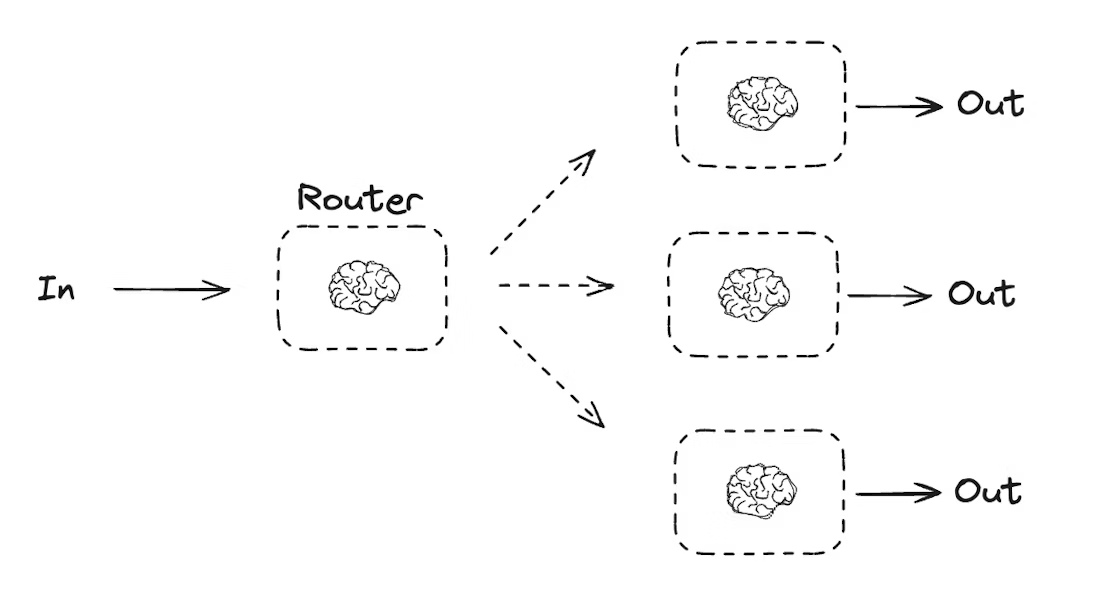


In [30]:
from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"




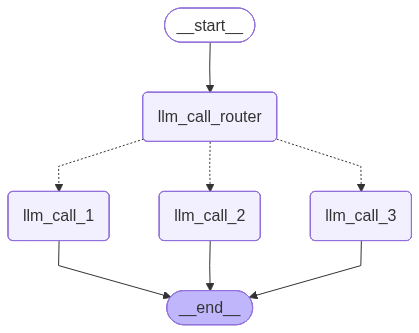

In [31]:
# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))


In [32]:

# Invoke
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])

Why don’t cats play poker in the wild?

Too many cheetahs! 🐱🃏

*(Bonus groan: And if they did, the ace of spades would just be a nap mat.)*


# Orchestrator-worker

In an orchestrator-worker configuration, the orchestrator:

*  Breaks down tasks into subtasks
*  Delegates subtasks to workers
*  Synthesizes worker outputs into a final result

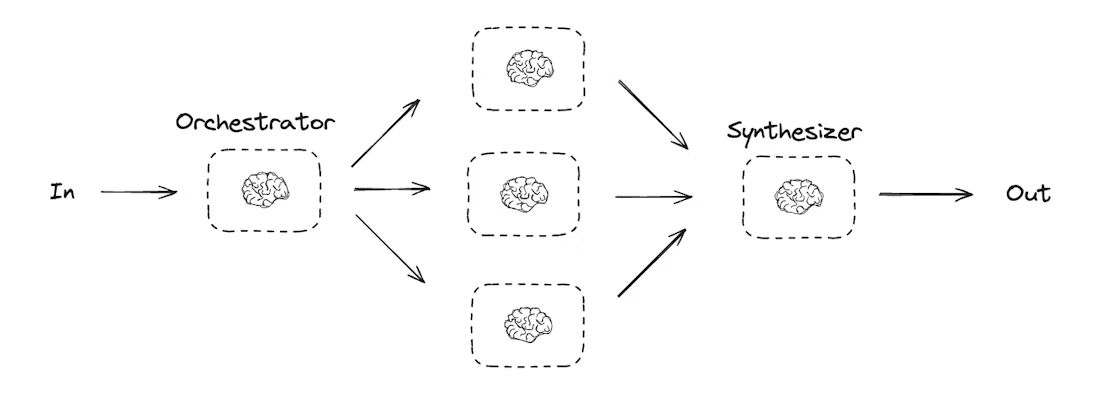

Orchestrator-worker workflows provide more flexibility and are often used when subtasks cannot be predefined the way they can with parallelization. This is common with workflows that write code or need to update content across multiple files. For example, a workflow that needs to update installation instructions for multiple Python libraries across an unknown number of documents might use this pattern.

In [41]:
from typing import Annotated, List
import operator


# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [44]:
results = planner.invoke('Create a report on LLM scaling laws')

('sections', [Section(name='Introduction', description='Overview of Large Language Models (LLMs) and the concept of scaling laws.'), Section(name='Historical Context', description='Evolution of scaling laws in machine learning and their application to LLMs.'), Section(name='Key Scaling Laws', description='Detailed explanation of the primary scaling laws including model size, dataset size, and compute.'), Section(name='Empirical Evidence', description='Summary of experiments and studies validating scaling laws in LLMs.'), Section(name='Practical Implications', description='How scaling laws influence model development, training, and resource allocation.'), Section(name='Limitations and Challenges', description='Discussion on the boundaries and potential breakdowns of scaling laws.'), Section(name='Future Directions', description='Emerging research and potential alternatives to traditional scaling approaches.')])


In [51]:
for r in results.sections:
    print(type(r))

<class '__main__.Section'>
<class '__main__.Section'>
<class '__main__.Section'>
<class '__main__.Section'>
<class '__main__.Section'>
<class '__main__.Section'>
<class '__main__.Section'>


In [36]:
from langgraph.types import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]




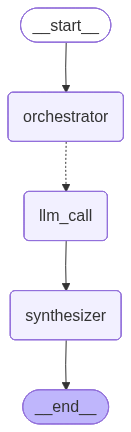

In [37]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))


In [38]:

# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})

from IPython.display import Markdown
Markdown(state["final_report"])

# Introduction and Description

Large Language Models (LLMs) are a class of deep learning models designed to understand and generate human-like text by training on vast corpora of textual data. Built primarily on the transformer architecture, LLMs such as GPT, PaLM, and LLaMA have demonstrated remarkable capabilities in tasks ranging from question answering and code generation to logical reasoning and multilingual translation—often without task-specific fine-tuning. These models leverage parameter counts in the billions to trillions, enabling them to capture intricate patterns in language and generalize across diverse domains.

A cornerstone of modern LLM development is the concept of scaling laws, which describe how model performance improves predictably as key resources—such as model size, dataset size, and computational budget—are increased. First systematically characterized by Kaplan et al. (2020), scaling laws reveal that loss decreases as a power law with respect to these factors, suggesting that performance gains are not merely incremental but can be anticipated and optimized through systematic scaling. This insight has transformed AI research by shifting focus from architectural innovation alone to resource-efficient scaling strategies, enabling more predictable and reproducible progress.

The importance of scaling laws lies in their ability to inform strategic investment in model development, guide resource allocation, and establish theoretical foundations for the emergent behaviors observed in large models. As such, they have become indispensable tools in modern AI research, underpinning the design of next-generation systems and fueling the ongoing race toward more capable, general-purpose artificial intelligence.

---

### Historical Context

The evolution of large language models (LLMs) has been marked by rapid advancements in model scale, training data, and architectural innovation. The journey began with GPT-2 (2019), developed by OpenAI, which demonstrated the potential of unsupervised pretraining on vast text corpora with 1.5 billion parameters. Though modest by today’s standards, GPT-2’s ability to generate coherent, contextually relevant text sparked widespread interest and concern over misuse.

In 2020, OpenAI released GPT-3, a landmark model with 175 billion parameters, trained on hundreds of gigabytes of text. GPT-3 exhibited emergent abilities—such as in-context learning and task generalization—without fine-tuning, fundamentally shifting the paradigm from task-specific models to general-purpose language systems. Its release catalyzed industry-wide investment in scaling laws and data efficiency.

Following GPT-3, competing efforts emerged. In 2021, Google introduced PaLM (Pathways Language Model) with 540 billion parameters, leveraging a novel Pathways architecture for efficient multi-task training across thousands of accelerators. Around the same time, Anthropic released Claude, emphasizing safety and alignment, while Meta launched LLaMA (2023), a family of open-weight models ranging from 7B to 65B parameters, democratizing access to high-performance LLMs.

In 2023, OpenAI unveiled GPT-4, a multimodal model with an estimated 1.8 trillion parameters (though not officially confirmed), capable of reasoning across text and images with significantly improved accuracy, instruction following, and reduced hallucination. Concurrently, Google released Gemini (2023), a native multimodal model designed from the ground up to handle text, code, audio, image, and video inputs with unified architecture, achieving state-of-the-art performance across benchmarks.

By 2024, the scaling trend continued with models like Mistral 7B and Mixtral (sparse Mixture-of-Experts), demonstrating that efficiency and performance could be balanced without exponential parameter growth. Meanwhile, Chinese tech firms such as Alibaba (Qwen) and Baidu (ERNIE Bot) released competitive models tailored for regional languages and regulatory environments.

This timeline reflects a consistent trajectory: increasing model size, expanding multimodal capabilities, and refining training methodologies—driven by advances in hardware, data curation, and algorithmic innovation. The field has moved from proof-of-concept models to complex, deployable systems shaping the future of human-AI interaction.

---

# Core Scaling Laws

The performance of large language models (LLMs) follows predictable empirical scaling laws that relate model size, dataset size, and compute budget to downstream task performance. These relationships are predominantly characterized by power-law behaviors, enabling reliable extrapolation of model capabilities under varying resource constraints.

The most widely validated scaling law, derived from extensive empirical studies (Kaplan et al., 2020; Hoffmann et al., 2022), expresses the expected loss $ L $ as a function of model parameters $ N $, training tokens $ D $, and compute $ C $, where $ C \propto N \cdot D $. The loss follows a power-law form:

$$
L(N, D) = \frac{A}{N^\alpha} + \frac{B}{D^\beta} + L_0
$$

where $ A, B, \alpha, \beta > 0 $ are fitted constants, and $ L_0 $ represents the irreducible loss. Typically, $ \alpha \approx 0.07 $–$ 0.1 $ and $ \beta \approx 0.05 $–$ 0.08 $, indicating that model size has a stronger impact on performance than dataset size, but both contribute significantly. This implies that optimal performance is achieved when compute is allocated proportionally between model size and data size — a principle known as the “Chinchilla optimal scaling” (Hoffmann et al., 2022), which suggests that for a fixed compute budget, model size and dataset size should be scaled equally (i.e., $ N \propto D $).

Compute budget $ C $, measured in floating-point operations (FLOPs), scales approximately as $ C \propto N \cdot D $, and the loss under optimal allocation follows:

$$
L(C) \propto C^{-\gamma}
$$

where $ \gamma \approx 0.05 $–$ 0.07 $, meaning that doubling compute reduces loss by roughly 5–7%. This power-law relationship holds across diverse architectures, tasks, and data domains, suggesting a universal scaling behavior in autoregressive language modeling.

Importantly, these laws exhibit saturation effects at extreme scales: beyond a certain point, gains from additional parameters or data diminish, and architectural innovations or data quality improvements become more impactful than pure scaling. Nevertheless, within the empirically validated regime (up to ~100B parameters and ~1T tokens), power-law scaling remains a robust predictor of model performance, forming the foundation for efficient training strategy design and resource planning in modern AI development.

---

### Empirical Evidence

Empirical studies from leading AI research organizations, including OpenAI and DeepMind, have consistently demonstrated that model performance scales predictably with increases in both model size and training data volume. OpenAI’s GPT series, particularly GPT-2, GPT-3, and GPT-4, revealed a power-law relationship between model performance (measured via language modeling loss, few-shot reasoning, and task generalization) and the number of parameters and tokens seen during training. For example, GPT-3 (175B parameters) trained on 570GB of text showed dramatic improvements over GPT-2 (1.5B parameters), achieving state-of-the-art results on dozens of benchmarks without task-specific fine-tuning.

Similarly, DeepMind’s Chinchilla study (2022) systematically analyzed the trade-offs between model size and data volume, demonstrating that for a fixed compute budget, optimal performance is achieved by balancing both parameters and training tokens — challenging the prior assumption that larger models alone yield the greatest gains. Chinchilla (70B parameters, trained on 1.4T tokens) outperformed GPT-3 (175B parameters, 300B tokens) across a wide range of tasks, highlighting the importance of data scale alongside model capacity.

Further evidence comes from DeepMind’s Gemini models and OpenAI’s o1 series, where scaling law extrapolations continue to hold even at unprecedented scales (>1000B parameters and multi-terabyte datasets). Performance gains are observed not only in language modeling but also in multi-modal reasoning, code generation, and mathematical problem-solving, with log-log plots of performance versus compute showing near-linear trends over several orders of magnitude. These findings collectively support the existence of robust scaling laws, suggesting that continued investment in both model scale and data quality remains a primary driver of AI capability advancements.

---

### Limitations and Challenges

Scaling AI and machine learning systems presents a suite of interrelated limitations and challenges that increasingly constrain efficiency, feasibility, and sustainability. One prominent issue is the phenomenon of diminishing returns: as model size and training data volume grow, the marginal gains in performance often decline significantly, while resource demands escalate disproportionately. This trend undermines the economic and practical rationale for continued scaling without corresponding architectural or algorithmic breakthroughs.

Computational costs have become prohibitive for many organizations. Training state-of-the-art models now requires thousands of specialized accelerators running for weeks or months, consuming hundreds of megawatt-hours of electricity. These costs not only limit access to cutting-edge research to well-funded entities but also create barriers to innovation in resource-constrained environments.

Data quality remains a persistent bottleneck. High-performance models are highly sensitive to noise, bias, and labeling inconsistencies in training datasets. Curating large-scale, high-fidelity datasets is labor-intensive, expensive, and often ethically fraught, particularly when sourcing data from unconsented or underrepresented populations. Poor data provenance and lack of transparency further erode model reliability and generalizability.

Environmental impacts are increasingly untenable. The carbon footprint of training large models can exceed that of multiple cars over their lifetimes. Energy consumption from data centers, cooling systems, and hardware manufacturing contributes to global emissions and strains local power grids. Without systemic shifts toward renewable energy, energy-efficient architectures, and model compression techniques, continued scaling risks exacerbating climate change and undermining the sustainability goals of the broader tech industry.

---

### Future Directions

Emerging trends in large model development are shifting focus from simplistic scale augmentation toward more sophisticated and efficient architectures and training paradigms. One prominent direction is the adoption of mixture-of-experts (MoE) models, which dynamically activate subsets of parameters per input, enabling significant gains in model capacity without proportional increases in compute or memory overhead. This sparse activation paradigm allows for models with trillions of parameters to remain economically trainable and inferable on existing hardware. Concurrently, efficient training techniques—such as low-rank adaptation (LoRA), parameter-efficient fine-tuning (PEFT), and gradient checkpointing optimizations—are reducing the carbon and financial footprint of model development while maintaining performance. Beyond these, alternative scaling strategies are gaining traction, including scaling along dimensions other than parameter count: depth-width trade-offs, data quality and diversity optimization, algorithmic improvements in optimization and loss functions, and hardware-aware model design. These approaches collectively point to a future where intelligence is not solely a function of size, but of architectural intelligence, computational efficiency, and targeted resource allocation.

---

### Conclusion

The analysis of large language model (LLM) scaling reveals a complex interplay between performance gains, resource intensity, and ethical trade-offs. While continued scaling has demonstrably improved task proficiency, generalization, and emergent capabilities, it has also exacerbated environmental costs, energy consumption, and concentration of computational power within a narrow set of institutions. The diminishing marginal returns on performance per unit of compute suggest that brute-force scaling is no longer a sustainable or equitable path forward.

For industry, these insights necessitate a strategic pivot: prioritizing efficiency over scale through model compression, sparse architectures, and specialized training techniques. Investment in open-weight models, data curation transparency, and energy-aware training protocols can mitigate monopolistic tendencies and foster broader innovation. Regulatory frameworks must evolve to require environmental impact disclosures and fairness audits for models above a certain scale.

For research, the focus must shift from scale-centric benchmarks to robustness, interpretability, and alignment under resource constraints. Novel methodologies—such as modular architectures, synthetic data generation, and human-in-the-loop refinement—offer promising alternatives to parameter growth. Longitudinal studies on societal impact, including labor displacement and misinformation amplification, are urgently needed to inform responsible development.

Ultimately, the sustainability and ethics of LLM scaling cannot be treated as secondary concerns. The environmental footprint of training frontier models rivals that of hundreds of households annually, while the lack of global equity in access and representation perpetuates systemic biases. Ethical scaling demands not only technical innovation but also institutional accountability, inclusive governance, and a redefinition of “progress” in AI. The future of LLMs must be measured not by parameters alone, but by their contribution to human well-being, planetary health, and democratic values.

In [39]:
state

{'topic': 'Create a report on LLM scaling laws',
 'sections': [Section(name='Introduction', description='Overview of Large Language Models (LLMs) and the concept of scaling laws, including their importance in modern AI research.'),
  Section(name='Historical Context', description='Timeline of key developments in LLM scaling, from early models like GPT-2 to state-of-the-art models such as GPT-4 and Gemini.'),
  Section(name='Core Scaling Laws', description='Explanation of the key scaling laws: model size, dataset size, and compute budget, including empirical relationships and power-law behaviors.'),
  Section(name='Empirical Evidence', description='Review of experimental results from major studies (e.g., OpenAI, DeepMind) demonstrating how performance scales with model and data size.'),
  Section(name='Limitations and Challenges', description='Discussion of diminishing returns, computational costs, data quality issues, and environmental impacts of scaling.'),
  Section(name='Future Dire

# Evaluator-optimizer


In evaluator-optimizer workflows, one LLM call creates a response and the other evaluates that response. If the evaluator or a human-in-the-loop determines the response needs refinement, feedback is provided and the response is recreated. This loop continues until an acceptable response is generated.


Evaluator-optimizer workflows are commonly used when there’s particular success criteria for a task, but iteration is required to meet that criteria. For example, there’s not always a perfect match when translating text between two languages. It might take a few iterations to generate a translation with the same meaning across the two languages.

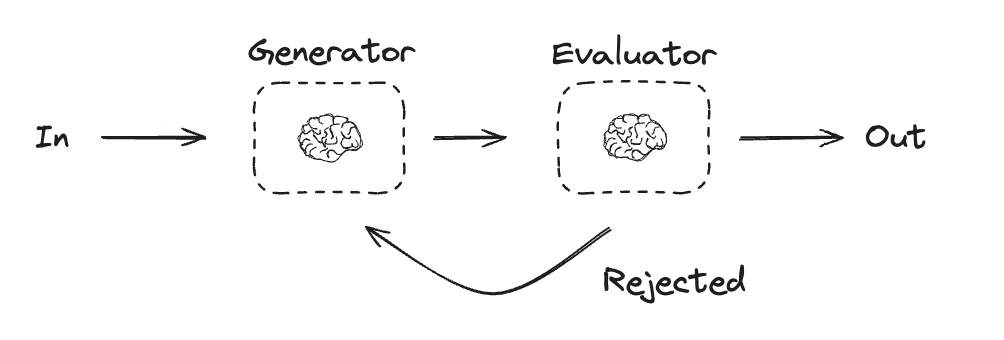

In [52]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)

In [53]:
evaluator.invoke('How are you doing today?')

Feedback(grade='not funny', feedback="This is not a joke, it's a question about well-being. To make it funny, try adding a humorous twist or unexpected punchline.")

In [80]:
# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


In [81]:
optimizer_builder = StateGraph(State)

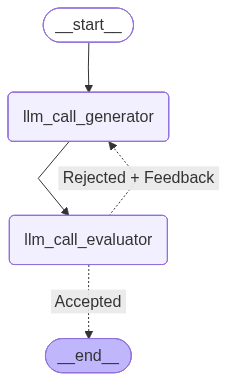

In [82]:
optimizer_builder.add_node('llm_call_generator',llm_call_generator)
optimizer_builder.add_node('llm_call_evaluator',llm_call_evaluator)

optimizer_builder.add_edge(START,'llm_call_generator')
optimizer_builder.add_edge('llm_call_generator','llm_call_evaluator')

optimizer_builder.add_conditional_edges('llm_call_evaluator', route_joke,
                                        {
                                            "Accepted": END,
                                            "Rejected + Feedback": 'llm_call_generator'
                                        }
                                        )


# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [83]:

# Invoke
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"])

Why don’t cats play poker in the wild?

Too many cheetahs. 🐱🃏

*(Bonus groan: And if they did, the ace of spades would just be a nap spot.)*


# Agents

Agents are typically implemented as an LLM performing actions using tools. They operate in continuous feedback loops, and are used in situations where problems and solutions are unpredictable. Agents have more autonomy than workflows, and can make decisions about the tools they use and how to solve problems. You can still define the available toolset and guidelines for how agents behave.


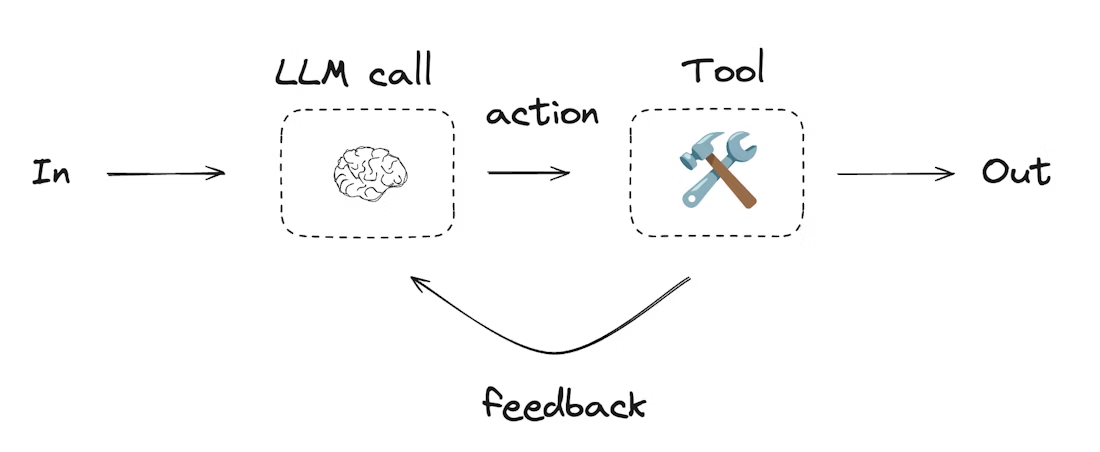

In [97]:
from langchain.tools import tool


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

In [98]:
result = llm_with_tools.invoke('What is 2 + 10 ?')
result.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 10},
  'id': 'call_bf7b12deff8a480496f030cc',
  'type': 'tool_call'}]

In [99]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


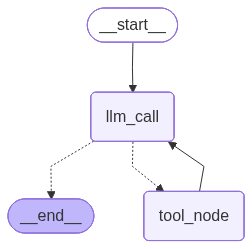

In [100]:


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [101]:

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_48c31cf905954da595f929e8)
 Call ID: call_48c31cf905954da595f929e8
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The result of adding 3 and 4 is 7.
